# Предсказание следующего товара



In [4]:
import json
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Чтобы графики отображались прямо в ноутбуке
%matplotlib inline

## 1. Загрузка данных

In [14]:
sessions = []

with open("/content/sessions.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            sessions.append(json.loads(line))

print(f"Всего сессий: {len(sessions)}")
print(f"Первая сессия: {sessions[0]}")
print(f"Минимальная длина сессии: {min(len(s) for s in sessions)}")

Всего сессий: 2565
Первая сессия: [380, 293, 262, 114, 123, 345, 335, 245, 272, 293, 233, 302, 247, 290, 260, 341, 293]
Минимальная длина сессии: 3


## 2. Анализ данных



In [15]:
session_lengths = [len(s) for s in sessions]

# все товары одним списком
all_items = [item for session in sessions for item in session]
item_counts = Counter(all_items)

print("Число сессий:", len(sessions))
print("Число уникальных товаров:", len(item_counts))
print("Всего просмотров товаров:", len(all_items))
print()
print("Длина сессии:")
print("  min:", np.min(session_lengths))
print("  mean:", round(np.mean(session_lengths), 2))
print("  median:", np.median(session_lengths))
print("  max:", np.max(session_lengths))
print()
print("Топ-10 популярных товаров:")
for item, cnt in item_counts.most_common(10):
    print(item, cnt)

Число сессий: 2565
Число уникальных товаров: 400
Всего просмотров товаров: 26843

Длина сессии:
  min: 3
  mean: 10.47
  median: 9.0
  max: 20

Топ-10 популярных товаров:
54 2914
335 1691
53 1223
114 1067
260 833
293 736
380 571
212 510
329 492
257 450


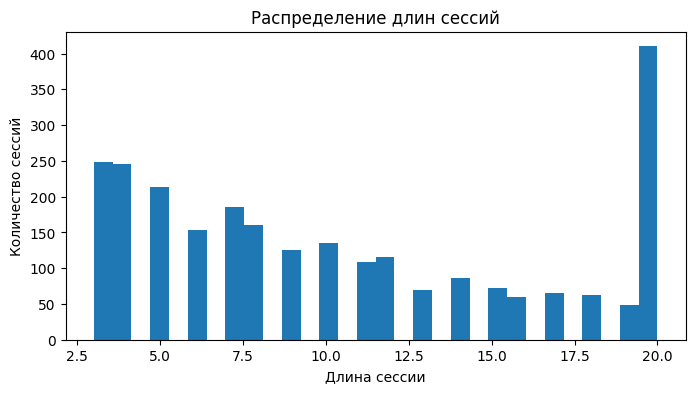

In [16]:
plt.figure(figsize=(8, 4))
plt.hist(session_lengths, bins=30)
plt.title("Распределение длин сессий")
plt.xlabel("Длина сессии")
plt.ylabel("Количество сессий")
plt.show()

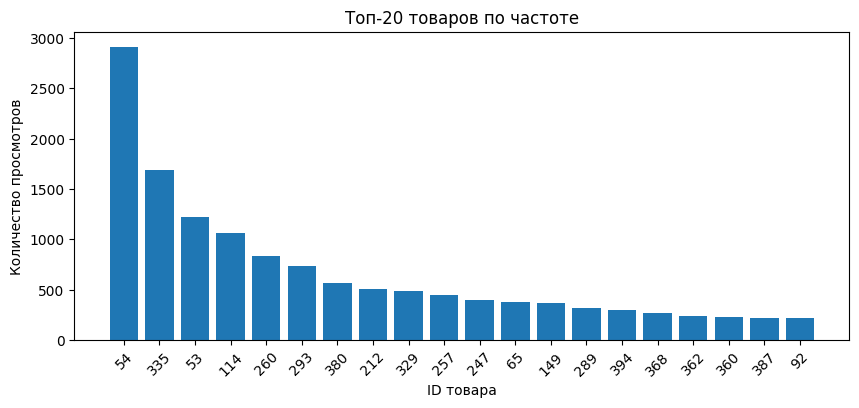

In [17]:
top_items = item_counts.most_common(20)
items = [str(x[0]) for x in top_items]
counts = [x[1] for x in top_items]

plt.figure(figsize=(10, 4))
plt.bar(items, counts)
plt.title("Топ-20 товаров по частоте")
plt.xlabel("ID товара")
plt.ylabel("Количество просмотров")
plt.xticks(rotation=45)
plt.show()

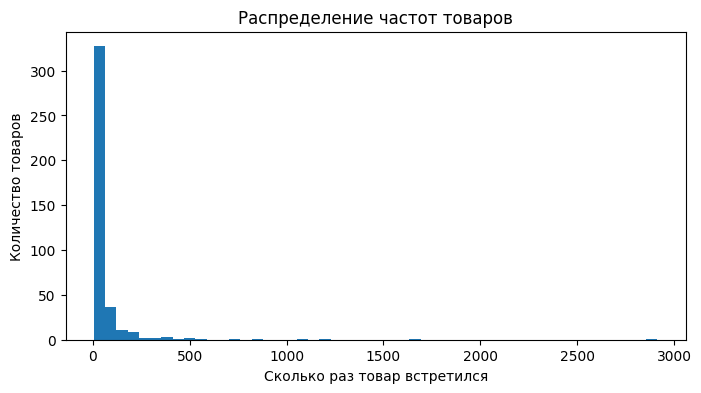

Товаров, которые встретились только 1 раз: 0
Доля таких товаров: 0.00%


In [18]:
count_values = list(item_counts.values())

plt.figure(figsize=(8, 4))
plt.hist(count_values, bins=50)
plt.title("Распределение частот товаров")
plt.xlabel("Сколько раз товар встретился")
plt.ylabel("Количество товаров")
plt.show()

rare_items = sum(1 for c in count_values if c == 1)
print(f"Товаров, которые встретились только 1 раз: {rare_items}")
print(f"Доля таких товаров: {rare_items / len(item_counts):.2%}")

## 3. Train/test split



In [19]:
def train_test_split(sessions: list[list[int]]) -> tuple[list[list[int]], list[int]]:
    train_sessions = [session[:-1] for session in sessions]
    test_targets = [session[-1] for session in sessions]
    return train_sessions, test_targets

train_sessions, test_targets = train_test_split(sessions)

print("Пример исходной сессии:", sessions[0])
print("История:", train_sessions[0])
print("Цель:", test_targets[0])

Пример исходной сессии: [380, 293, 262, 114, 123, 345, 335, 245, 272, 293, 233, 302, 247, 290, 260, 341, 293]
История: [380, 293, 262, 114, 123, 345, 335, 245, 272, 293, 233, 302, 247, 290, 260, 341]
Цель: 293


## 4. Граф переходов



In [20]:
def build_transition_counts(train_sessions: list[list[int]]):
    transition_counts = defaultdict(Counter)

    for session in train_sessions:
        for current_item, next_item in zip(session[:-1], session[1:]):
            transition_counts[current_item][next_item] += 1

    return transition_counts

transition_counts = build_transition_counts(train_sessions)

print("Товаров, у которых есть исходящие переходы:", len(transition_counts))

# пример для одного товара
example_item = next(iter(transition_counts))
print("Пример товара:", example_item)
print("Переходы после него:", transition_counts[example_item].most_common(5))

Товаров, у которых есть исходящие переходы: 400
Пример товара: 380
Переходы после него: [(293, 99), (114, 90), (54, 35), (132, 17), (335, 16)]


In [24]:
def build_transition_probs(transition_counts):
    transition_probs = {}

    for item, next_counter in transition_counts.items():
        total = sum(next_counter.values())
        transition_probs[item] = {
            next_item: count / total
            for next_item, count in next_counter.items()
        }

    return transition_probs

transition_probs = build_transition_probs(transition_counts)

## 5. Рекомендательная модель



In [25]:
popular_items = [item for item, cnt in item_counts.most_common()]

def recommend_next_items(
    history: list[int],
    transition_counts,
    popular_items: list[int],
    k: int = 10,
) -> list[int]:
    if not history:
        return popular_items[:k]

    last_item = history[-1]
    recommendations = []

    if last_item in transition_counts:
        candidates = transition_counts[last_item].most_common()
        for item, count in candidates:
            if item != last_item and item not in recommendations:
                recommendations.append(item)
            if len(recommendations) == k:
                break

    for item in popular_items:
        if len(recommendations) == k:
            break
        if item != last_item and item not in recommendations:
            recommendations.append(item)

    return recommendations

print("Пример истории:", train_sessions[0])
print("Рекомендации:", recommend_next_items(train_sessions[0], transition_counts, popular_items, k=10))
print("Истинный следующий товар:", test_targets[0])

Пример истории: [380, 293, 262, 114, 123, 345, 335, 245, 272, 293, 233, 302, 247, 290, 260, 341]
Рекомендации: [92, 149, 54, 287, 7, 212, 12, 260, 380, 335]
Истинный следующий товар: 293


## 6. Оценка качества: Hit@10

In [26]:
def hit_at_k(recommendations: list[list[int]], true_items: list[int], k: int = 10) -> float:
    assert len(recommendations) == len(true_items), "Длины списков должны совпадать"

    hits = 0
    for recs, true_item in zip(recommendations, true_items):
        if true_item in recs[:k]:
            hits += 1

    return hits / len(true_items)

In [27]:
model_recommendations = [
    recommend_next_items(history, transition_counts, popular_items, k=10)
    for history in train_sessions
]

model_hit = hit_at_k(model_recommendations, test_targets, k=10)
print(f"Hit@10 модели переходов: {model_hit:.4f}")

Hit@10 модели переходов: 0.5142


## 7. Бейзлайн: 10 самых популярных товаров


In [28]:
train_all_items = [item for session in train_sessions for item in session]
train_item_counts = Counter(train_all_items)
train_popular_items = [item for item, cnt in train_item_counts.most_common()]

baseline_top10 = train_popular_items[:10]
baseline_recommendations = [baseline_top10 for _ in train_sessions]

baseline_hit = hit_at_k(baseline_recommendations, test_targets, k=10)
print("Топ-10 популярных товаров:", baseline_top10)
print(f"Hit@10 бейзлайна: {baseline_hit:.4f}")

Топ-10 популярных товаров: [54, 335, 53, 114, 260, 293, 380, 212, 329, 257]
Hit@10 бейзлайна: 0.3840


In [29]:
result_df = pd.DataFrame({
    "model": ["popular_top10", "transition_model"],
    "hit@10": [baseline_hit, model_hit],
})

result_df

,model,hit@10
0,popular_top10,0.384016
1,transition_model,0.514230


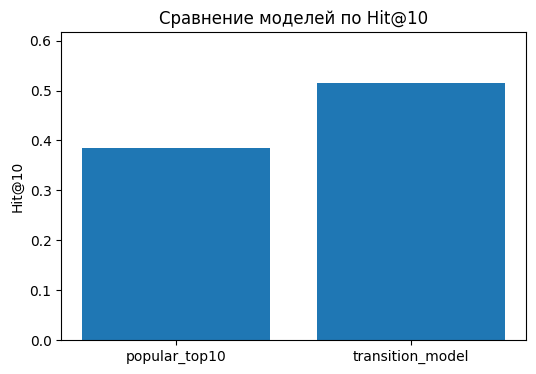

In [30]:
plt.figure(figsize=(6, 4))
plt.bar(result_df["model"], result_df["hit@10"])
plt.title("Сравнение моделей по Hit@10")
plt.ylabel("Hit@10")
plt.ylim(0, max(result_df["hit@10"]) * 1.2 if max(result_df["hit@10"]) > 0 else 1)
plt.show()

## 8. Небольшой анализ результата

Я проанализировала, что сессии в основном не очень длинные, чаще всего пользователь смотрит несколько товаров подряд.Также видно, что некоторые товары встречаются гораздо чаще других - это значит,что есть популярные товары.Из этого можно сделать вывод, что простой бейзлайн на основе популярности уже может давать неплохой результат.


## 9. Проверка нескольких примеров

In [31]:
for i in range(5):
    print("История:", train_sessions[i])
    print("Рекомендации:", model_recommendations[i])
    print("Истинный товар:", test_targets[i])
    print("Попал?", test_targets[i] in model_recommendations[i])
    print("-" * 50)

История: [380, 293, 262, 114, 123, 345, 335, 245, 272, 293, 233, 302, 247, 290, 260, 341]
Рекомендации: [92, 149, 54, 287, 7, 212, 12, 260, 380, 335]
Истинный товар: 293
Попал? False
--------------------------------------------------
История: [53, 54, 53, 65, 53, 335, 286]
Рекомендации: [335, 54, 154, 247, 216, 53, 114, 260, 293, 380]
Истинный товар: 335
Попал? True
--------------------------------------------------
История: [54, 397, 398, 294, 223, 293]
Рекомендации: [114, 380, 54, 191, 335, 132, 262, 129, 260, 316]
Истинный товар: 233
Попал? False
--------------------------------------------------
История: [335, 54, 335, 221, 41, 247, 380, 114, 43, 111, 257, 335, 54, 62, 387, 362]
Рекомендации: [212, 387, 54, 335, 62, 177, 230, 53, 194, 323]
Истинный товар: 387
Попал? True
--------------------------------------------------
История: [252, 301, 387, 212, 246, 61, 175, 392, 370, 233]
Рекомендации: [247, 319, 54, 399, 302, 66, 114, 84, 53, 361]
Истинный товар: 92
Попал? False
-----------